# Bouquet: DIII-D Equilibrium 201586

This notebook generates a **bouquet** of 15 perturbed equilibria from a
single DIII-D baseline equilibrium (shot 201586, 4200 ms), with the goal of
 **providing various inputs to BOUT++** for further analysis.

## Workflow overview

1. **Load inputs** — g-file (`g201586.04200`) and IDA cdf-file (`IDA_201584_.cdf`).
2. **Reconstruct the baseline equilibrium** in TokaMaker using the DIII-D mesh.
3. **Generate 15 perturbed equilibria** via GPR sampling (`generate_bouquet`).

### Input files

| File | Description |
|---|---|
| `g201586.04200` | EFIT magnetic equilibrium (geqdsk format) |
| `IDA_201584_.cdf` | Kinetic profiles (IDA format) |
| `DIIID_mesh.h5` | Pre-built TokaMaker finite-element mesh for DIII-D |

## 1. Imports

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.ndimage import uniform_filter1d
from omfit_classes.omfit_nc import OMFITnc

%matplotlib inline
%config InlineBackend.figure_format = "retina"

# --- TokaMaker ---
sys.path.append('/Applications/OpenFUSIONToolkit/python')
# tokamaker_python_path = '/Users/danielburgess/Desktop/plasma/OpenFUSIONToolkit/build_release'
# if tokamaker_python_path is not None:
#     sys.path.append(os.path.join(tokamaker_python_path, 'python'))

from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_power_flux_fun

# --- Bouquet ---
from bouquet import (
    read_geqdsk,
    reconstruct_equilibrium,
    generate_bouquet,
    initialize_equilibrium_database,
    store_equilibrium,
    calc_cylindrical_li_proxy,
    plot_tokamaker_comparison,
    plot_bouquet,
)
from bouquet.io.pfile import read_pfile
from bouquet import new_uncertainty_profiles
from bouquet import sigmoid_length_scale

print(f"Working directory: {os.getcwd()}")

Working directory: /Users/oaknelson/Documents/GitHub/bouquet/IDA_workflow/201586


## 2. User configuration

All tunable parameters are collected here.  Key choices:

- **Uncertainties for $n_e$, $T_e$, $T_i$** are computed from raw data
  (see §3) rather than using a fixed fractional envelope.
- **$j_\phi$ uncertainty** uses a flat 10% fractional envelope (standard).
- **GPR length scales** are kept at standard D3D values.
- **`n_equils = 15`** perturbed equilibria to generate.

In [2]:
# ----- Input files -----
geqdsk_file = 'g201586.04200'
IDA_file  = 'IDA_201586_.cdf'

header = '201586_04200_IDA'  # HDF5 database name (without .h5)

target_time = 4200 # ms

# ----- DIII-D machine files -----
MESH_FILE = 'DIIID_mesh.h5'   # Pre-built TokaMaker mesh for DIII-D

# ----- j_phi uncertainty (flat fractional envelope — kept as-is) -----
frac_jphi = 0.10

# ----- GPR correlation length scales (in psi_N units — kept as-is) -----
n_ls = 0.6    # density
t_ls = 0.5    # temperature
j_ls = 0.3    # current density

# ----- Perturbation settings -----
n_equils = 15        # number of perturbed equilibria
jBS_scale_range = [0.8, 1.2]  # bootstrap current multiplicative range
pad_psi  = 1e-3      # LCFS psi padding for TokaMaker queries

# ----- Ion species for p-file (from p-file footer) -----
ion_N = [6, 1, 1]
ion_Z = [6, 1, 1]
ion_A = [12, 2, 2]

# ----- Which posterior summary to use for the uncertainty band -----
# 'std'         → mean ± 1 std  (Gaussian-like summary)
# 'percentile'  → median + 16th/84th percentile band (robust to outliers)
UNCERTAINTY_METHOD = 'percentile'   # change to 'std' if preferred

# ----- Output directory for figures -----
FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

print(f"Will generate {n_equils} perturbed equilibria")
print(f"Figures will be saved to: {FIG_DIR}/")

Will generate 15 perturbed equilibria
Figures will be saved to: figures/


## 3. Compute 1σ uncertainties from raw profile data

The file `profiles_data.npz` contains raw measurement data for $n_e$,
$T_e$, and $T_i$ (e.g. from Thomson scattering and charge-exchange
recombination spectroscopy).  These are scattered measurements at
various $\psi_N$ locations.

The p-file contains the **fitted** (smooth) profiles.  The approach:

1. Interpolate the fitted p-file profile onto the raw measurement $\psi_N$ grid.
2. Compute **residuals** = raw data − fitted profile.
3. Compute a **rolling standard deviation** of residuals (window size
   controlled by `SMOOTH_WINDOW`) to get a smooth, radially-varying
   $\sigma(\psi_N)$.
4. Interpolate this smooth $\sigma(\psi_N)$ onto the g-file's uniform
   $\psi_N$ grid for use in bouquet.

This captures the actual measurement scatter rather than assuming a
fixed fractional uncertainty, giving a more faithful representation
of where the profiles are well-constrained vs. uncertain.

**Note:** We only use raw data for $n_e$, $T_e$, $T_i$.  The $n_i$
uncertainty is derived from $n_e$ (via quasi-neutrality), and the
$j_\phi$ uncertainty uses a standard flat 10% envelope.

In [3]:
# ---- Load IDA posterior samples ----
cdf = OMFITnc(IDA_file)

pf_time = np.array(cdf['time']['data']) / 1e3   # ms → s

# Shape of each array: (n_times, n_samples, n_radial) = (1, 1024, 129)
pf_ne   = cdf['n_e']['data']     / 1e20   # m^-3  → 10^20/m^3
pf_te   = cdf['T_e']['data']     / 1e3    # eV    → keV
pf_ti   = cdf['T_12C6']['data']  / 1e3    # eV    → keV
pf_psin = cdf['psi_n']['data']            # (n_times, n_samples, n_radial)

# Select first (only) time slice → shape (n_samples, n_radial)
t_idx      = 0
ne_samples = pf_ne[t_idx]    # (1024, 129)
te_samples = pf_te[t_idx]
ti_samples = pf_ti[t_idx]
psin_ida   = pf_psin[t_idx, 0, :]   # radial grid is the same for all samples

print(f"IDA grid: {psin_ida.shape[0]} radial points, "
      f"psiN = [{psin_ida[0]:.4f}, {psin_ida[-1]:.4f}]")
print(f"Posterior samples: {ne_samples.shape[0]}")
print(f"ne(0) mean  = {ne_samples[:, 0].mean():.4f} x 10^20/m^3")
print(f"te(0) mean  = {te_samples[:, 0].mean():.4f} keV")
print(f"ti(0) mean  = {ti_samples[:, 0].mean():.4f} keV")

IDA grid: 150 radial points, psiN = [0.0000, 1.2000]
Posterior samples: 1024
ne(0) mean  = 0.7601 x 10^20/m^3
te(0) mean  = 2.7226 keV
ti(0) mean  = 2.7417 keV


In [4]:
def summarise_samples(samples, method=UNCERTAINTY_METHOD):
    """
    Reduce (n_samples, n_radial) posterior draws to a central value and
    a 1σ-equivalent uncertainty band.

    Parameters
    ----------
    samples : ndarray, shape (n_samples, n_radial)
    method  : 'std' or 'percentile'

    Returns
    -------
    centre : ndarray (n_radial,)   – mean or median
    lo     : ndarray (n_radial,)   – centre − 1σ  (or 16th percentile)
    hi     : ndarray (n_radial,)   – centre + 1σ  (or 84th percentile)
    sigma  : ndarray (n_radial,)   – half-width of the band (hi − centre)
    """
    if method == 'std':
        centre = samples.mean(axis=0)
        sigma  = samples.std(axis=0)
        lo     = centre - sigma
        hi     = centre + sigma
    else:  # percentile
        centre = np.median(samples, axis=0)
        lo     = np.percentile(samples, 16, axis=0)
        hi     = np.percentile(samples, 84, axis=0)
        sigma  = (hi - lo) / 2.0   # symmetric half-width for downstream use
    return centre, lo, hi, sigma

In [5]:
# ---- Summarise posteriors ----
ne_centre, ne_lo, ne_hi, sigma_ne = summarise_samples(ne_samples)
te_centre, te_lo, te_hi, sigma_te = summarise_samples(te_samples)
ti_centre, ti_lo, ti_hi, sigma_ti = summarise_samples(ti_samples)

# ni: derive from ne uncertainty (quasi-neutrality)
# Assumes ni ≈ ne (or scale by Zeff if available)
sigma_ni  = sigma_ne.copy()
ni_centre = ne_centre.copy()

print(f"\nne sigma: core={sigma_ne[0]:.4f}, mid={sigma_ne[len(psin_ida)//2]:.4f}, "
      f"edge={sigma_ne[-5]:.4f}  (10^20/m^3)")
print(f"te sigma: core={sigma_te[0]:.4f}, mid={sigma_te[len(psin_ida)//2]:.4f}, "
      f"edge={sigma_te[-5]:.4f}  (keV)")
print(f"ti sigma: core={sigma_ti[0]:.4f}, mid={sigma_ti[len(psin_ida)//2]:.4f}, "
      f"edge={sigma_ti[-5]:.4f}  (keV)")

mid = len(psin_ida) // 2
print(f"\nFractional uncertainties at psiN≈0.5:")
print(f"  ne: {sigma_ne[mid]/max(ne_centre[mid], 1e-30):.1%}")
print(f"  te: {sigma_te[mid]/max(te_centre[mid], 1e-30):.1%}")
print(f"  ti: {sigma_ti[mid]/max(ti_centre[mid], 1e-30):.1%}")


ne sigma: core=0.0335, mid=0.0153, edge=0.0032  (10^20/m^3)
te sigma: core=0.1016, mid=0.0351, edge=0.0005  (keV)
ti sigma: core=0.2337, mid=0.0372, edge=0.0144  (keV)

Fractional uncertainties at psiN≈0.5:
  ne: 2.8%
  te: 8.5%
  ti: 8.5%


In [6]:
# ---- Load g-file to get the target psi_N grid ----
eqdsk = read_geqdsk(geqdsk_file)
psi_N = eqdsk.psi_N  # uniform grid, 0 to 1

print(f"g-file psi_N grid: {len(psi_N)} points")

# ---- Interpolate IDA summaries onto g-file grid (for bouquet) ----
def interp_to_grid(psin_src, arr, psin_tgt):
    return interp1d(psin_src, arr,
                    kind='linear', bounds_error=False,
                    fill_value=(arr[0], arr[-1]))(psin_tgt)

ne_fit_grid    = interp_to_grid(psin_ida, ne_centre, psi_N)
te_fit_grid    = interp_to_grid(psin_ida, te_centre, psi_N)
ti_fit_grid    = interp_to_grid(psin_ida, ti_centre, psi_N)
sigma_ne_grid  = interp_to_grid(psin_ida, sigma_ne,  psi_N)
sigma_te_grid  = interp_to_grid(psin_ida, sigma_te,  psi_N)
sigma_ti_grid  = interp_to_grid(psin_ida, sigma_ti,  psi_N)

g-file psi_N grid: 65 points


### 3a. Diagnostic plots: raw data, fitted profiles, and uncertainty envelopes

These plots show:
- **Left column:** Raw measurement data (dots) overlaid on the fitted p-file
  profile (black line) with the computed ±1σ band (shaded).
- **Right column:** The smooth 1σ uncertainty envelope $\sigma(\psi_N)$.

This verifies that the uncertainty envelopes faithfully capture the
measurement scatter.

Saved: figures/uncertainty_estimation.png


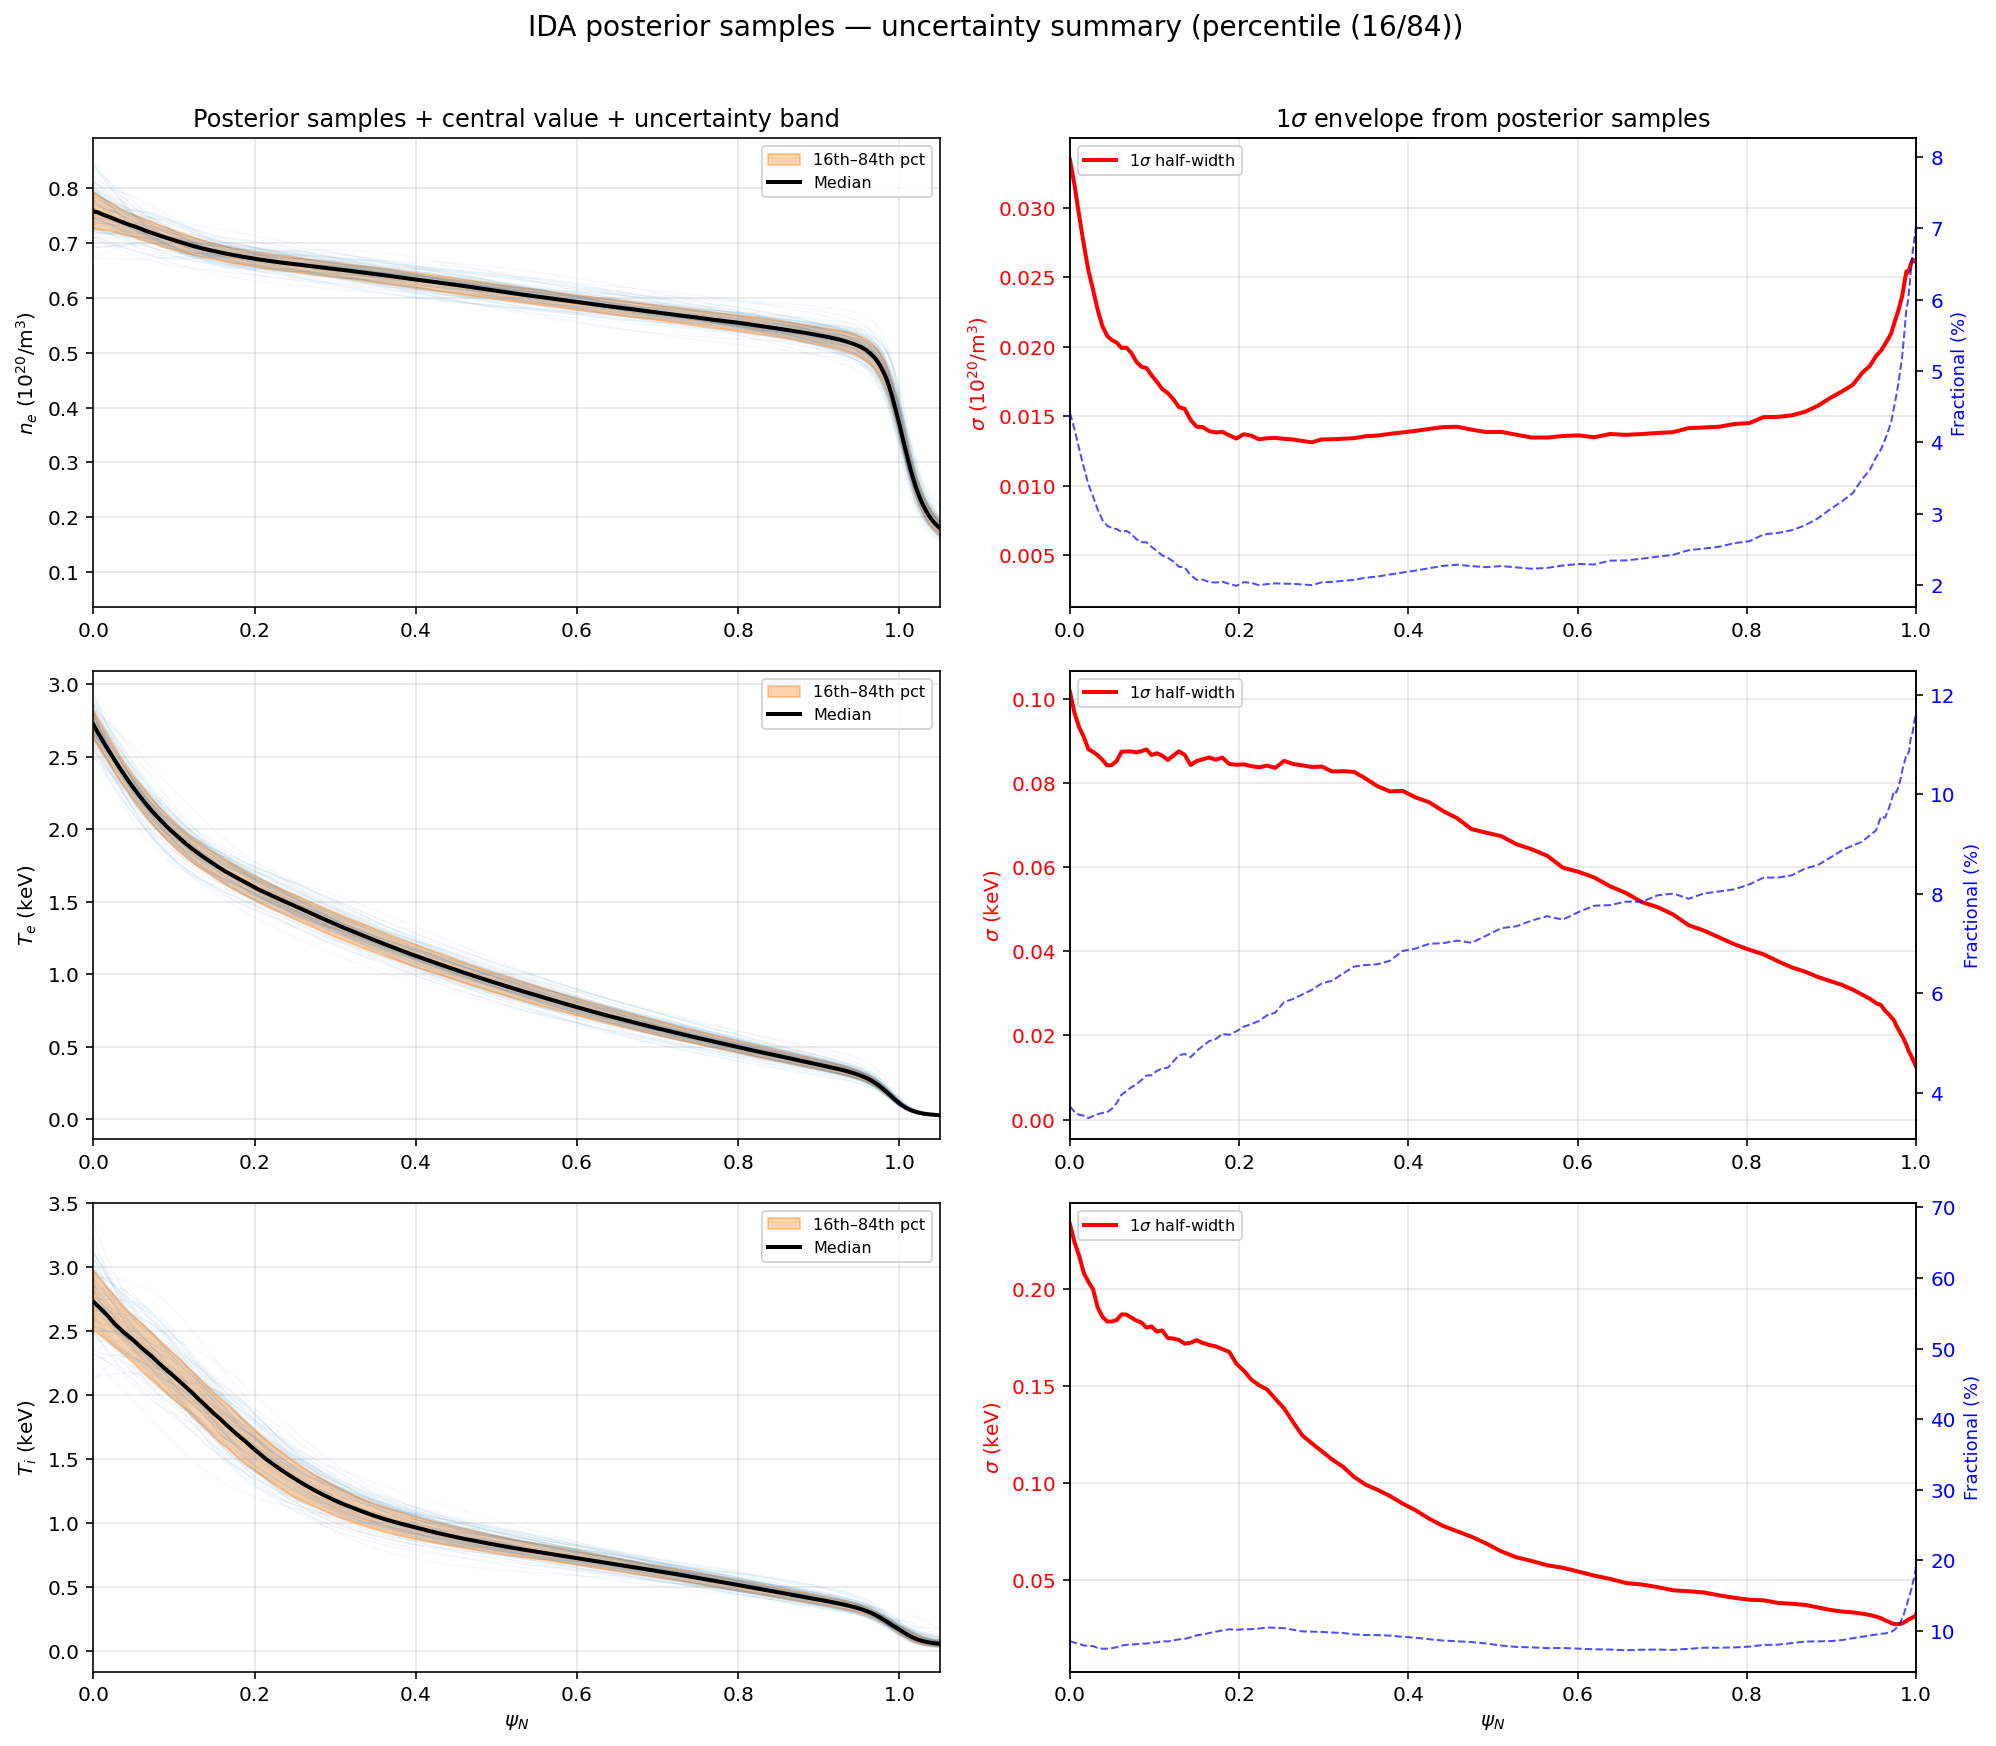

In [7]:
# Thin out samples for the spaghetti overlay (all 1024 would be slow)
N_SPAGHETTI = 100
rng = np.random.default_rng(42)
idx = rng.choice(ne_samples.shape[0], size=N_SPAGHETTI, replace=False)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

profiles_info = [
    ('$n_e$', r'($10^{20}$/m$^3$)',
     ne_samples[idx], ne_centre, ne_lo, ne_hi, sigma_ne),
    ('$T_e$', '(keV)',
     te_samples[idx], te_centre, te_lo, te_hi, sigma_te),
    ('$T_i$', '(keV)',
     ti_samples[idx], ti_centre, ti_lo, ti_hi, sigma_ti),
]

band_label = (r'16th–84th pct' if UNCERTAINTY_METHOD == 'percentile'
              else r'mean $\pm 1\sigma$')

for row, (name, unit, spaghetti, centre, lo, hi, sigma) in enumerate(profiles_info):

    # ---- Left: posterior spaghetti + central value + band ----
    ax = axes[row, 0]
    for s in spaghetti:
        ax.plot(psin_ida, s, color='tab:blue', alpha=0.05, lw=0.6)
    ax.fill_between(psin_ida, lo, hi,
                    alpha=0.35, color='tab:orange', label=band_label)
    ax.plot(psin_ida, centre, 'k-', lw=2,
            label='Median' if UNCERTAINTY_METHOD == 'percentile' else 'Mean')
    ax.set_ylabel(f'{name} {unit}')
    ax.set_xlim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    if row == 0:
        ax.set_title('Posterior samples + central value + uncertainty band')

    # ---- Right: uncertainty width + fractional uncertainty ----
    ax = axes[row, 1]
    ax.plot(psin_ida, sigma, 'r-', lw=2, label=r'$1\sigma$ half-width')
    ax.set_ylabel(f'$\\sigma$ {unit}', color='r')
    ax.tick_params(axis='y', labelcolor='r')

    ax2 = ax.twinx()
    frac = sigma / np.maximum(np.abs(centre), 1e-30)
    ax2.plot(psin_ida, frac * 100, 'b--', lw=1, alpha=0.7)
    ax2.set_ylabel('Fractional (%)', color='b', fontsize=9)
    ax2.tick_params(axis='y', labelcolor='b')

    ax.set_xlim(0, 1.0)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)
    if row == 0:
        ax.set_title(r'$1\sigma$ envelope from posterior samples')

for ax in axes[-1, :]:
    ax.set_xlabel(r'$\psi_N$')

method_str = 'percentile (16/84)' if UNCERTAINTY_METHOD == 'percentile' else 'mean ± std'
fig.suptitle(f'IDA posterior samples — uncertainty summary ({method_str})',
             fontsize=14, y=1.01)
plt.tight_layout()

fig.savefig(os.path.join(FIG_DIR, 'uncertainty_estimation.png'),
            dpi=150, bbox_inches='tight')
print(f"Saved: {FIG_DIR}/uncertainty_estimation.png")
plt.show()

## 4. Initialize TokaMaker

We use the pre-built DIII-D mesh (`DIIID_mesh.h5`), define conductor
and coil regions, and call `setup()` with the toroidal field
$F_0 = R_0 B_0$ read from the g-file.

> **Note:** Only one `TokaMaker` instance can exist per Python kernel.

In [8]:
myOFT = OFT_env(nthreads=2)
mygs  = TokaMaker(myOFT)

# Load DIII-D mesh
mesh_pts, mesh_lc, mesh_reg, coil_dict, cond_dict = load_gs_mesh(MESH_FILE)
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict, coil_dict=coil_dict)

# Read F0 = R0*B0 from the g-file
eqdsk_ref = read_geqdsk(geqdsk_file)
F0 = abs(eqdsk_ref.R_center * eqdsk_ref.B_center)

mygs.setup(order=3, F0=F0)
mygs.settings.maxits = 200
mygs.settings.pm = False
mygs.update_settings()

# Vertical stability coil pair (F9A/F9B antisymmetric)
mygs.set_coil_vsc({'F9A': 1.0, 'F9B': -1.0})

print(f'F0 = {F0:.4f} T·m')
print(f'DIII-D mesh loaded: {len(mesh_pts)} points')
print('TokaMaker initialized for DIII-D.')

#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:    main
Revision id:           b8ff58b
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2
Fortran input file    = /var/folders/05/5bk04kj15rg64s4vd1hd6r0m0000gn/T/oft_37155/oftpyin
XML input file        = none
Integer Precisions    =    4   8
Float Precisions      =    4   8  10
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.574E+01
    # of points  =    8910
    # of edges   =   26567
    # of cells   =   17658
    # of boundary points =     160
    # of boundary edges  =     160
    # of boundary cells  =     160
  Resolution statistics:
    hmin =  8.702E-04
    hrms =  4.833E-02
    hmax =  1.540E-01
  Surface grounded at vertex    1733


**** Creati

In [9]:
# ---- Isoflux from g-file boundary ----
# Use the 199749 g-file boundary shape as isoflux targets
isoflux_pts     = np.column_stack([eqdsk_ref.boundary_R, eqdsk_ref.boundary_Z])
isoflux_weights = np.ones(len(isoflux_pts)) * 500.0
mygs.set_isoflux(isoflux_pts, weights=isoflux_weights)

print(f"Isoflux: {len(isoflux_pts)} target points from g199749.03350 boundary")

Isoflux: 90 target points from g199749.03350 boundary


In [10]:
# ---- DIII-D coil regularisation ----
# Use weak regularisation toward zero for all coils.
# The inverse solver in reconstruct_equilibrium will find
# appropriate coil currents to match the g-file boundary.
regularization_terms = []
for name in mygs.coil_sets:
    regularization_terms.append(
        mygs.coil_reg_term({name: 1.0}, target=0.0, weight=1.0))

# Small weight on the virtual VSC to allow up-down adjustment
regularization_terms.append(
    mygs.coil_reg_term({'#VSC': 1.0}, target=0.0, weight=1e-2))

mygs.set_coil_reg(reg_terms=regularization_terms)

print(f'Coil regularisation set for {len(mygs.coil_sets)} DIII-D coil sets.')
print('TokaMaker fully initialized for DIII-D.')

Coil regularisation set for 20 DIII-D coil sets.
TokaMaker fully initialized for DIII-D.


## 5. Reconstruct baseline equilibrium

We reconstruct the baseline equilibrium (shot 199749, 3350 ms) in
TokaMaker using `reconstruct_equilibrium()`.  This:

1. Decomposes $j_\phi$ into bootstrap ($j_{\text{BS}}$) and inductive
   ($j_{\text{ind}}$) components via TokaMaker's Sauter model.
2. Iterates on the inductive scale factor to match the g-file $l_i$.
3. Corrects residual $I_p$ drift.

The kinetic profiles are read from the p-file and converted to SI units
($n_e$ in m$^{-3}$, $T_e$ in eV) as required by the reconstruction routine.

In [11]:
# ---- Prepare SI profiles from IDA posterior means ----

# --- Load Zeff samples from IDA ---
zeff_samples = cdf['Zeff']['data'][t_idx]          # (n_samples, n_radial)
zeff_centre  = zeff_samples.mean(axis=0)
zeff_centre  = np.clip(zeff_centre, 1.0, None)

# --- Interpolate onto g-file psi_N grid in SI units ---
ne_SI   = interp_to_grid(psin_ida, ne_centre,   psi_N) * 1e20   # m^-3
te_SI   = interp_to_grid(psin_ida, te_centre,   psi_N) * 1e3    # eV
ni_SI   = interp_to_grid(psin_ida, ne_centre,   psi_N) * 1e20   # m^-3  (quasi-neutrality approx)
ti_SI   = interp_to_grid(psin_ida, ti_centre,   psi_N) * 1e3    # eV
Zeff_eq = interp_to_grid(psin_ida, zeff_centre, psi_N)
Zeff_eq = np.clip(Zeff_eq, 1.0, None)

print(f"Profiles interpolated onto {len(psi_N)}-point psi_N grid.")
print(f"ne(0) = {ne_SI[0]:.3e} m^-3")
print(f"te(0) = {te_SI[0]:.1f} eV")
print(f"Zeff(0) = {Zeff_eq[0]:.2f}")
print(f"Ip    = {eqdsk.Ip:.3e} A")

Profiles interpolated onto 65-point psi_N grid.
ne(0) = 7.582e+19 m^-3
te(0) = 2722.8 eV
Zeff(0) = 1.58
Ip    = 9.956e+05 A


In [12]:
# ---- Set isoflux targets from 199749 boundary shape ----
isoflux_pts_eq = np.column_stack([eqdsk.boundary_R, eqdsk.boundary_Z])
isoflux_weights_eq = np.ones(len(eqdsk.boundary_R)) * 500.0
mygs.set_isoflux(isoflux_pts_eq, weights=isoflux_weights_eq)

# ---- Initial guess for inductive j_phi shape ----
nr = len(psi_N)
guess_jinductive = create_power_flux_fun(nr, 1.5, 1.5)['y']

# ---- Reconstruct ----
print("Starting equilibrium reconstruction...")
print("This may take a few minutes.\n")

result = reconstruct_equilibrium(
    mygs, eqdsk,
    ne_SI, te_SI, ni_SI, ti_SI, Zeff_eq,
    isoflux_pts_eq, isoflux_weights_eq, pad_psi,
    guess_jinductive=guess_jinductive,
    n_k=5,
    psi_bridge=0.99,
    rescale_j_BS=False,
    shelf_psi_N=0.0,
    initialize_psi=True,
)

print("\nReconstruction complete.")

Starting equilibrium reconstruction...
This may take a few minutes.


 >>> Matching input core j_phi with G-S solution



 >>> Finding optimal j_phi scale factor

--- Checking scale_j0 = 1.0000 ---
   Input j_0:  1.1801e+06
   Output j_0: 1.2947e+06
   Mismatch:  8.846%

--- Checking scale_j0 = 1.2000 ---
   Input j_0:  1.4001e+06
   Output j_0: 1.3221e+06
   Mismatch:  5.899%
--- Optimization Iteration 1 ---

--- Checking scale_j0 = 1.1190 ---
   Input j_0:  1.3110e+06
   Output j_0: 1.3120e+06
   Mismatch:  0.072%
Converged! Optimal scale factor: 1.1190

 >>> Finding optimal Ip scale factor

--- Checking scale_Ip = 1.0000 ---
   Input Ip target:  9.9560e-01
   Trial Ip target:  9.9560e-01
   Output Ip: 1.0124e+00
   Mismatch:  1.6892%

--- Checking scale_Ip = 0.9900 ---
   Input Ip target:  9.9560e-01
   Trial Ip target:  9.8564e-01
   Output Ip: 1.0016e+00
   Mismatch:  0.6058%
--- Optimization Iteration 1 ---

--- Checking scale_Ip = 0.9844 ---
   Input Ip target:  9.9560e-01
   Trial Ip target:  9.8007e-01
   Output Ip: 9.9558e-01
   Mismatch:  0.0022%
Converged! Optimal scale factor: 0.9844

 >>> I

In [13]:
# ---- Store baseline equilibrium in HDF5 database ----
db_path = f"{header}.h5"
if os.path.exists(db_path):
    os.remove(db_path)
    print(f"Deleted existing {db_path}")

db = initialize_equilibrium_database(header)

eqdsk_out = f"{header}_baseline.geqdsk"
eqdsk_out_abs = os.path.abspath(eqdsk_out)
mygs.save_eqdsk(eqdsk_out, nr=257, nz=257,
                truncate_eq=False, lcfs_pad=pad_psi)

li1 = mygs.get_stats(lcfs_pad=pad_psi, li_normalization='std')['l_i']
li3 = mygs.get_stats(lcfs_pad=pad_psi, li_normalization='iter')['l_i']

store_equilibrium(
    header, 0, eqdsk_out_abs,
    psi_N,
    result['j_phi_fit'],
    result['j_BS_used'],
    result['j_inductive_fit'],
    ne_SI, te_SI, ni_SI, ti_SI,
    np.zeros_like(ti_SI),  # w_ExB placeholder
    li1, li3,
)

os.remove(eqdsk_out)
print(f"Baseline stored: li(1)={li1:.4f}, li(3)={li3:.4f}")

Deleted existing 201586_04200_IDA.h5
Saving gEQDSK: 201586_04200_IDA_baseline.geqdsk
Baseline stored: li(1)=1.0281, li(3)=0.7227


## 6. Verify reconstruction

Compare the TokaMaker reconstruction against the original g-file to
ensure fidelity before generating perturbations.

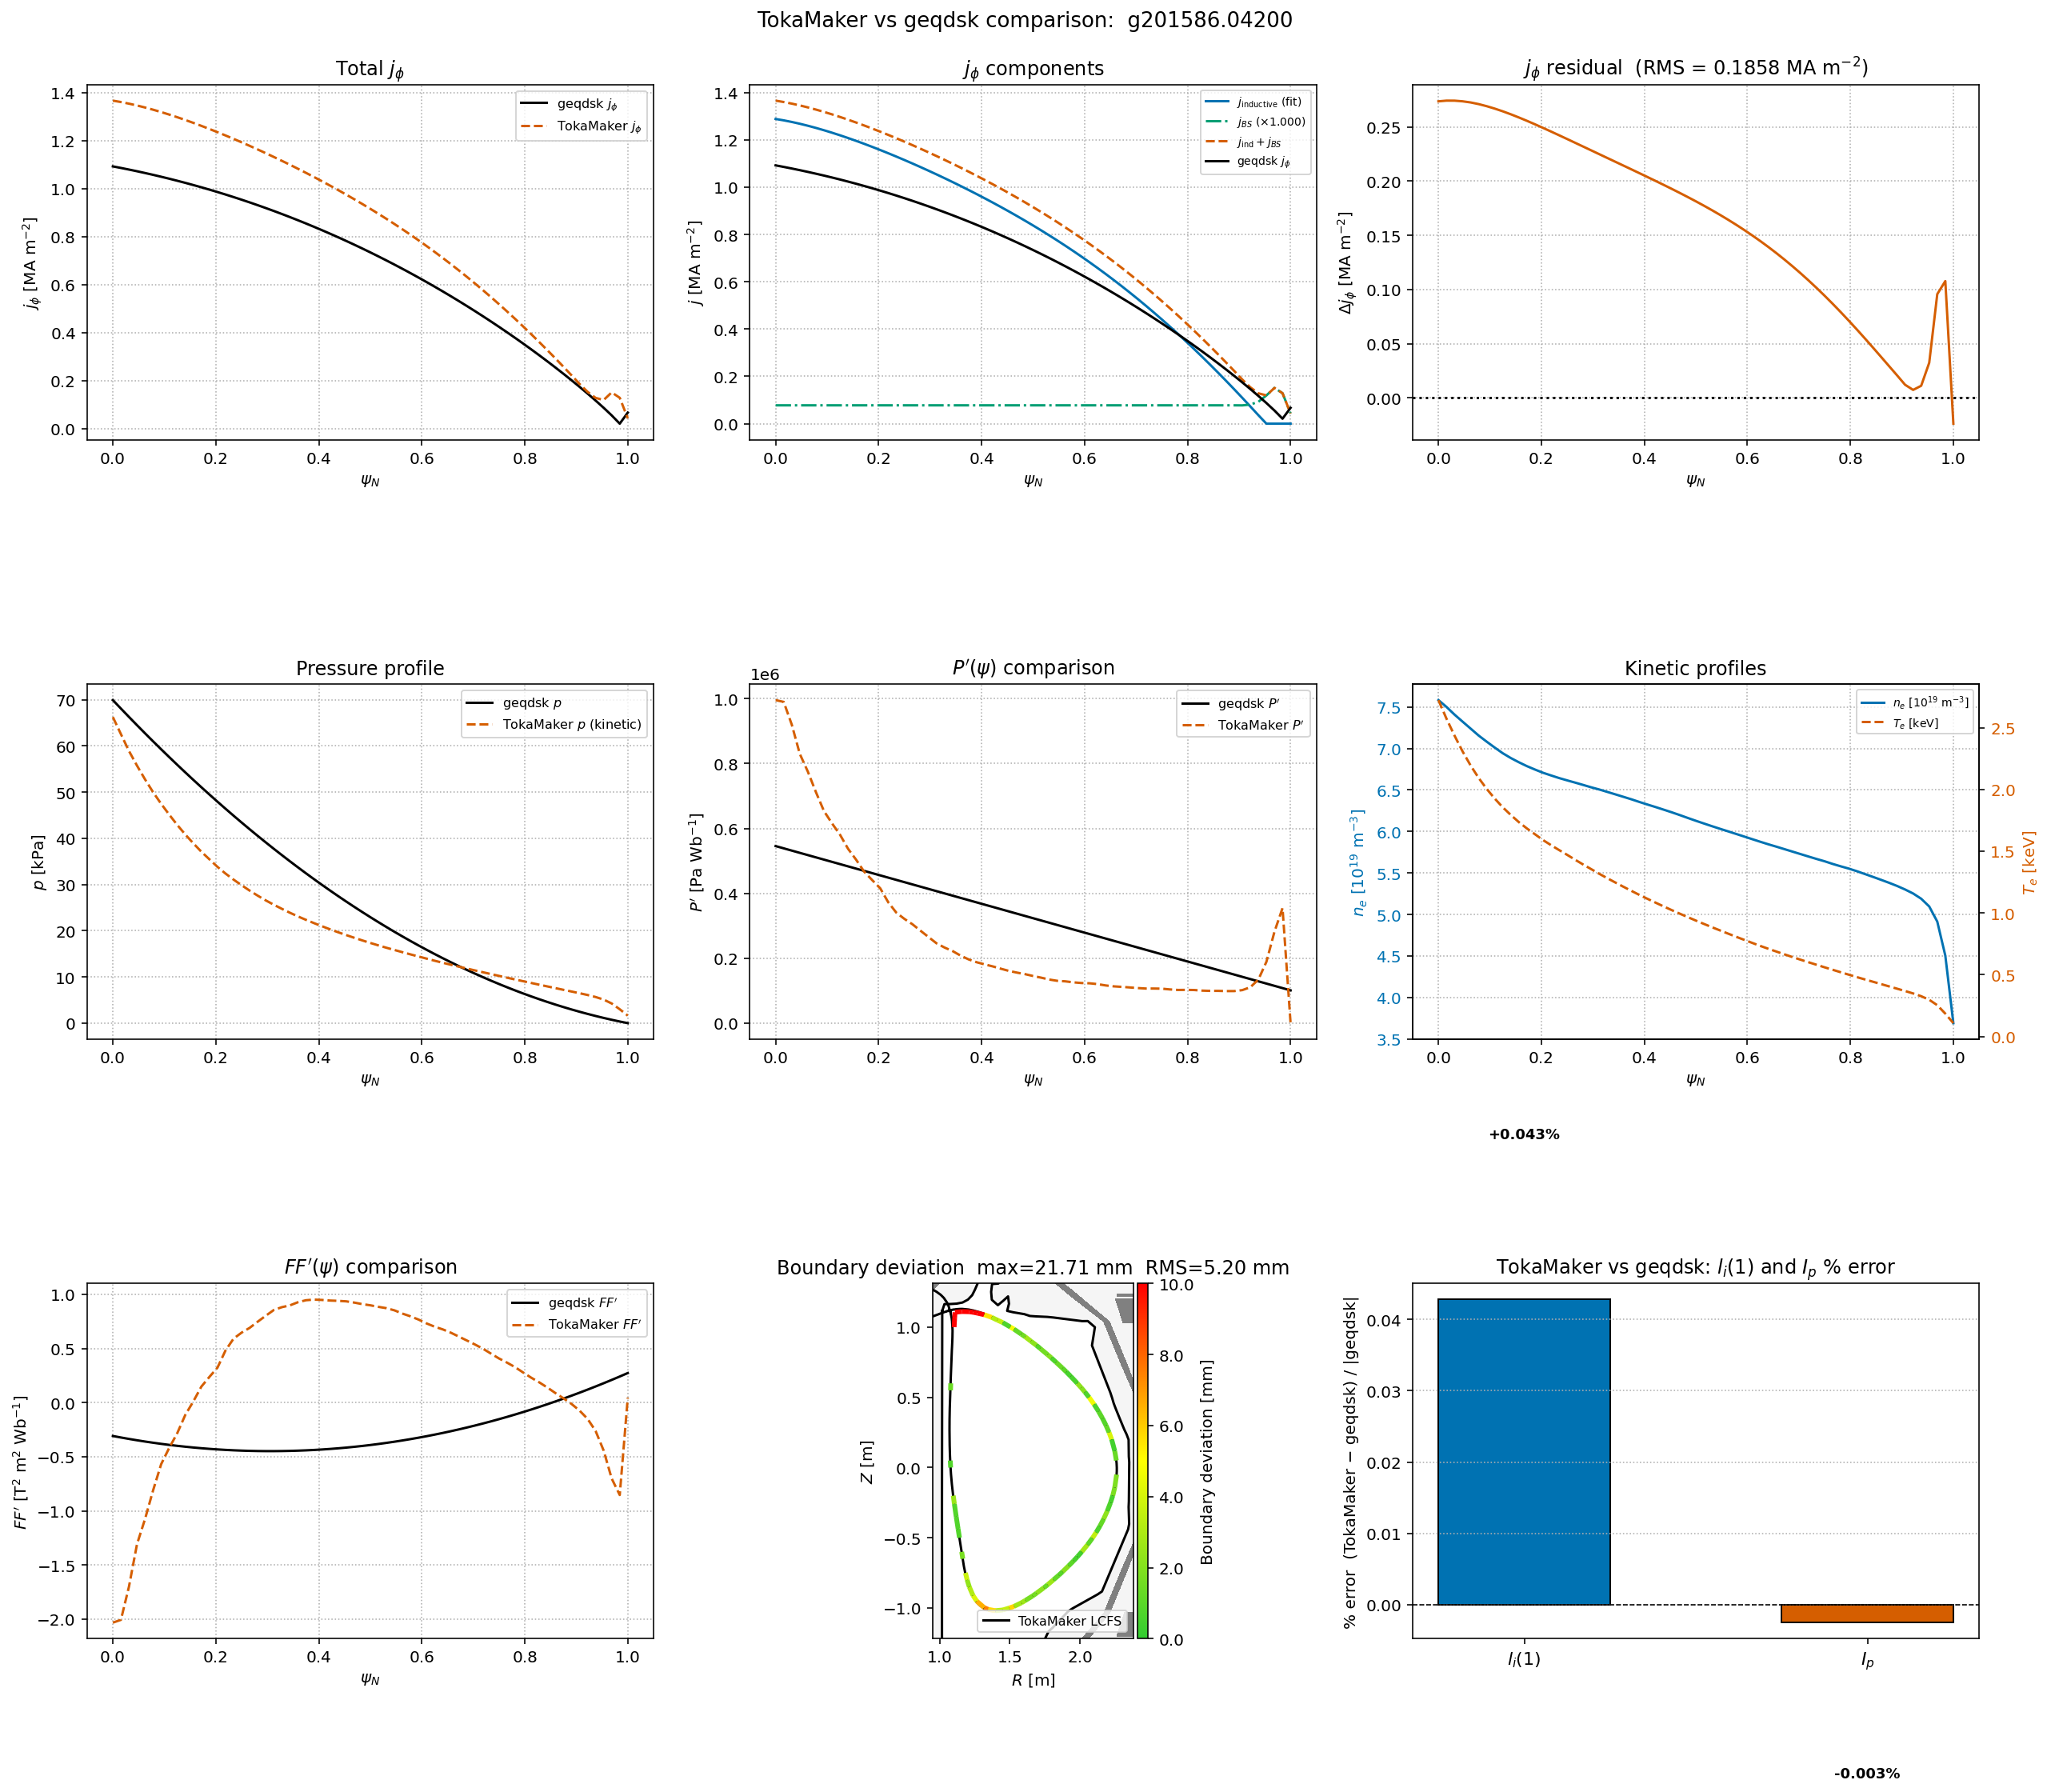


--- Summary for g201586.04200 ---
  bs_factor_final : 1.000000
  li(1) achieved  : 1.028074
  j_phi RMS error : 185774.44 A/m^2  (0.1858 MA/m^2)
  eqdsk Ip        : 995598 A
  TokaMaker Ip    : 995572 A  (-0.003%)
  Boundary dev.   : max=21.71 mm  RMS=5.20 mm
Saved: figures/reconstruction_comparison.png


<Figure size 432x288 with 0 Axes>

In [14]:
all_results = {geqdsk_file: result}
plot_tokamaker_comparison(mygs, all_results, plot_idx=0)

plt.savefig(os.path.join(FIG_DIR, 'reconstruction_comparison.png'), dpi=150, bbox_inches='tight')
print(f"Saved: {FIG_DIR}/reconstruction_comparison.png")
plt.show()

## 7. Generate perturbed equilibrium family

We now generate **15 perturbed equilibria** using `generate_bouquet()`.

### Uncertainty inputs

- **$n_e$, $T_e$, $T_i$:** Data-driven 1σ envelopes computed in §3 from
  raw measurement scatter. These are converted to SI units (m$^{-3}$, eV)
  to match the profile units used by bouquet.
- **$n_i$:** Derived from $n_e$ uncertainty via quasi-neutrality.
- **$j_\phi$:** Flat 10% fractional envelope (standard).
- **Length scales:** Kept at standard SPARC values ($n$: 0.6, $T$: 0.5,
  $j$: 0.3 in $\psi_N$ units).

Each perturbed equilibrium:
1. Draws GPR-perturbed profiles within the uncertainty envelopes.
2. Recomputes bootstrap current.
3. Iterates to match baseline $I_p$ and $l_i$.

In [15]:
# ---- Convert posterior uncertainties to SI on g-file grid ----
# sigma_*_grid are in 10^20/m^3 (ne/ni) and keV (te/ti), on psi_N grid

sigma_ne_SI = sigma_ne_grid * 1e20   # m^-3
sigma_te_SI = sigma_te_grid * 1e3    # eV
sigma_ni_SI = sigma_ne_grid * 1e20   # m^-3  (same fractional uncertainty as ne)
sigma_ti_SI = sigma_ti_grid * 1e3    # eV

# j_phi: flat fractional envelope (unchanged)
sigma_jphi = frac_jphi * np.abs(result['j_phi_fit'])

print("Uncertainty profiles converted to SI:")
print(f"  sigma_ne(0): {sigma_ne_SI[0]:.3e} m^-3  ({sigma_ne_SI[0]/ne_SI[0]*100:.1f}% of ne)")
print(f"  sigma_te(0): {sigma_te_SI[0]:.1f} eV  ({sigma_te_SI[0]/te_SI[0]*100:.1f}% of te)")
print(f"  sigma_ti(0): {sigma_ti_SI[0]:.1f} eV  ({sigma_ti_SI[0]/ti_SI[0]*100:.1f}% of ti)")
print(f"  sigma_jphi:  flat {frac_jphi*100:.0f}%")

Uncertainty profiles converted to SI:
  sigma_ne(0): 3.345e+18 m^-3  (4.4% of ne)
  sigma_te(0): 101.6 eV  (3.7% of te)
  sigma_ti(0): 233.7 eV  (8.6% of ti)
  sigma_jphi:  flat 10%


In [16]:
# ---- Targets from reconstruction ----
Ip_target  = abs(eqdsk.Ip)
l_i_target = mygs.get_stats(lcfs_pad=pad_psi, li_normalization='std')['l_i']

# Read baseline files as raw bytes for HDF5 archival
with open(geqdsk_file, 'rb') as fh:
    baseline_eqdsk_raw = fh.read()
with open(IDA_file, 'rb') as fh:
    ida_raw_bytes = fh.read()

# Restore isoflux targets
mygs.set_isoflux(result['isoflux_pts'], weights=result['weights'])

print(f"Generating {n_equils} perturbed equilibria...")
print(f"  Ip target:  {Ip_target/1e6:.3f} MA")
print(f"  li target:  {l_i_target:.4f}")
print(f"  jBS scale:  {jBS_scale_range}")
print()

diagnostics = generate_bouquet(
    mygs, psi_N, n_equils, header,
    result['j_phi_fit'],
    ne_SI, te_SI, ni_SI, ti_SI,
    sigma_ne_SI, sigma_te_SI, sigma_ni_SI, sigma_ti_SI, sigma_jphi,
    n_ls, t_ls, j_ls,
    Ip_target, l_i_target, Zeff_eq,
    input_jinductive=result['j_inductive_fit'],
    l_i_tolerance=0.03,
    l_i_proxy_threshold=1.5,
    psi_pad=pad_psi,
    constrain_sawteeth=True,
    recalculate_j_BS=True,
    jBS_scale_range=jBS_scale_range,
    pfile_bytes=ida_raw_bytes,
    baseline_eqdsk_bytes=baseline_eqdsk_raw,
    baseline_pfile_bytes=ida_raw_bytes,
    diagnostic_plots=False,
    scan_val=0,
)

print(f"\n{len(diagnostics)} perturbed equilibria generated and archived.")

Generating 15 perturbed equilibria...
  Ip target:  0.996 MA
  li target:  1.0281
  jBS scale:  [0.8, 1.2]



Traceback (most recent call last):
  File "/Users/oaknelson/Documents/GitHub/bouquet/bouquet/TokaMaker_interface.py", line 821, in generate_bouquet
    pf_bl = _PFile.from_bytes(baseline_pfile_bytes)
  File "/Users/oaknelson/Documents/GitHub/bouquet/bouquet/io/pfile.py", line 246, in from_bytes
    return cls(tmp_path)
  File "/Users/oaknelson/Documents/GitHub/bouquet/bouquet/io/pfile.py", line 230, in __init__
    self._raw = _read_pfile(filename)
  File "/Users/oaknelson/Documents/GitHub/bouquet/bouquet/io/pfile.py", line 115, in _read_pfile
    lines = f.read().strip().splitlines()
  File "/Users/oaknelson/opt/anaconda3/lib/python3.10/codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte


Bouquet:   0%|          | 0/15 [00:00<?, ?eq/s]


  Equilibrium 1/15  (scale_jBS=0.8304)
Searching for pressure profile match...
  [li_iter=1] Proxy matched in 2 draws (0.5s, err=0.015%)
  [li_iter=1] find_optimal_scale: 8.5s
  l_i target (equil):   1.0281
  proxy target:         1.0619  (corrected)
  matched l_i (equil):  1.0027
  matched l_i (proxy):  1.0470
  Ip error vs target:   0.001%
  proxy vs real l_i:    +4.42%
  |l_i - l_i_target|:   0.0253
  Wall-clock time: 32.1s  (total: 0.5 min, avg: 32.1s/eq)
  Saving to: /Users/oaknelson/Documents/GitHub/bouquet/IDA_workflow/201586/201586_04200_IDA_count=0.geqdsk
Saving gEQDSK: 201586_04200_IDA_count=0.geqdsk
  Deleted temporary file: /Users/oaknelson/Documents/GitHub/bouquet/IDA_workflow/201586/201586_04200_IDA_count=0.geqdsk

  Equilibrium 2/15  (scale_jBS=0.8024)  ETA: 7.5 min
Searching for pressure profile match...


Traceback (most recent call last):
  File "/Users/oaknelson/Documents/GitHub/bouquet/bouquet/TokaMaker_interface.py", line 982, in generate_bouquet
    pf = _PFile.from_bytes(pfile_bytes)
  File "/Users/oaknelson/Documents/GitHub/bouquet/bouquet/io/pfile.py", line 246, in from_bytes
    return cls(tmp_path)
  File "/Users/oaknelson/Documents/GitHub/bouquet/bouquet/io/pfile.py", line 230, in __init__
    self._raw = _read_pfile(filename)
  File "/Users/oaknelson/Documents/GitHub/bouquet/bouquet/io/pfile.py", line 115, in _read_pfile
    lines = f.read().strip().splitlines()
  File "/Users/oaknelson/opt/anaconda3/lib/python3.10/codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte


...

Traceback (most recent call last):
  File "/Users/oaknelson/Documents/GitHub/bouquet/bouquet/TokaMaker_interface.py", line 982, in generate_bouquet
    pf = _PFile.from_bytes(pfile_bytes)
  File "/Users/oaknelson/Documents/GitHub/bouquet/bouquet/io/pfile.py", line 246, in from_bytes
    return cls(tmp_path)
  File "/Users/oaknelson/Documents/GitHub/bouquet/bouquet/io/pfile.py", line 230, in __init__
    self._raw = _read_pfile(filename)
  File "/Users/oaknelson/Documents/GitHub/bouquet/bouquet/io/pfile.py", line 115, in _read_pfile
    lines = f.read().strip().splitlines()
  File "/Users/oaknelson/opt/anaconda3/lib/python3.10/codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte


  [li_iter=1] Proxy matched in 12 draws (1.0s, err=0.477%)
  [li_iter=1] find_optimal_scale: 13.2s
  l_i target (equil):   1.0281
  proxy target:         1.0510  (corrected)
  matched l_i (equil):  0.9880
  matched l_i (proxy):  1.0276
  Ip error vs target:   0.010%
  proxy vs real l_i:    +4.01%
  |l_i - l_i_target|:   0.0401
  [li_iter=2] Proxy matched in 21 draws (4.7s, err=0.664%)
  [li_iter=2] find_optimal_scale: 12.2s
  l_i target (equil):   1.0281
  proxy target:         1.0621  (corrected)
  matched l_i (equil):  1.0212
  matched l_i (proxy):  1.0597
  Ip error vs target:   0.005%
  proxy vs real l_i:    +3.78%
  |l_i - l_i_target|:   0.0069
  Wall-clock time: 68.3s  (total: 14.4 min, avg: 60.5s/eq)
  Saving to: /Users/oaknelson/Documents/GitHub/bouquet/IDA_workflow/201586/201586_04200_IDA_count=13.geqdsk
Saving gEQDSK: 201586_04200_IDA_count=13.geqdsk
  Deleted temporary file: /Users/oaknelson/Documents/GitHub/bouquet/IDA_workflow/201586/201586_04200_IDA_count=13.geqdsk

  Equ

Traceback (most recent call last):
  File "/Users/oaknelson/Documents/GitHub/bouquet/bouquet/TokaMaker_interface.py", line 982, in generate_bouquet
    pf = _PFile.from_bytes(pfile_bytes)
  File "/Users/oaknelson/Documents/GitHub/bouquet/bouquet/io/pfile.py", line 246, in from_bytes
    return cls(tmp_path)
  File "/Users/oaknelson/Documents/GitHub/bouquet/bouquet/io/pfile.py", line 230, in __init__
    self._raw = _read_pfile(filename)
  File "/Users/oaknelson/Documents/GitHub/bouquet/bouquet/io/pfile.py", line 115, in _read_pfile
    lines = f.read().strip().splitlines()
  File "/Users/oaknelson/opt/anaconda3/lib/python3.10/codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte


  [li_iter=1] Proxy matched in 24 draws (2.7s, err=1.408%)
  [li_iter=1] find_optimal_scale: 12.8s
  l_i target (equil):   1.0281
  proxy target:         1.0606  (corrected)
  matched l_i (equil):  0.9605
  matched l_i (proxy):  1.0103
  Ip error vs target:   0.004%
  proxy vs real l_i:    +5.19%
  |l_i - l_i_target|:   0.0676
  [li_iter=2] Proxy matched in 7 draws (1.9s, err=0.446%)
  [li_iter=2] find_optimal_scale: 11.6s
  l_i target (equil):   1.0281
  proxy target:         1.0578  (corrected)
  matched l_i (equil):  1.0456
  matched l_i (proxy):  1.0746
  Ip error vs target:   0.003%
  proxy vs real l_i:    +2.78%
  |l_i - l_i_target|:   0.0175
  Wall-clock time: 63.3s  (total: 15.4 min, avg: 60.7s/eq)
  Saving to: /Users/oaknelson/Documents/GitHub/bouquet/IDA_workflow/201586/201586_04200_IDA_count=14.geqdsk
Saving gEQDSK: 201586_04200_IDA_count=14.geqdsk
  Deleted temporary file: /Users/oaknelson/Documents/GitHub/bouquet/IDA_workflow/201586/201586_04200_IDA_count=14.geqdsk

15 per

Traceback (most recent call last):
  File "/Users/oaknelson/Documents/GitHub/bouquet/bouquet/TokaMaker_interface.py", line 982, in generate_bouquet
    pf = _PFile.from_bytes(pfile_bytes)
  File "/Users/oaknelson/Documents/GitHub/bouquet/bouquet/io/pfile.py", line 246, in from_bytes
    return cls(tmp_path)
  File "/Users/oaknelson/Documents/GitHub/bouquet/bouquet/io/pfile.py", line 230, in __init__
    self._raw = _read_pfile(filename)
  File "/Users/oaknelson/Documents/GitHub/bouquet/bouquet/io/pfile.py", line 115, in _read_pfile
    lines = f.read().strip().splitlines()
  File "/Users/oaknelson/opt/anaconda3/lib/python3.10/codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x89 in position 0: invalid start byte


## 8. Visualize the bouquet

Plot the family of perturbed profiles (kinetic, pressure, and $j_\phi$)
overlaid on the baseline with uncertainty bands.

Saved: figures/bouquet_all_profiles.png


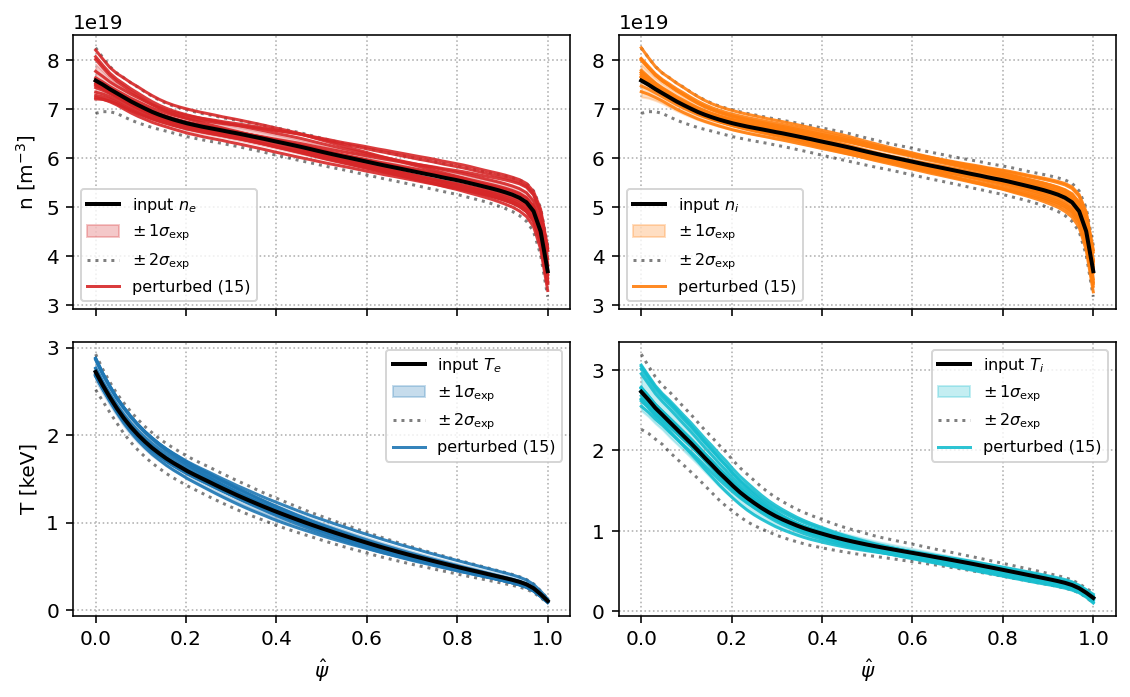

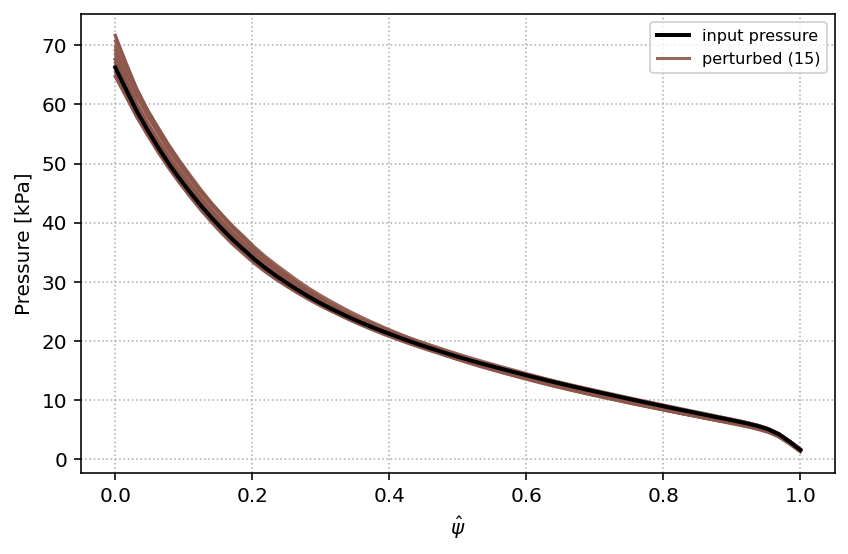

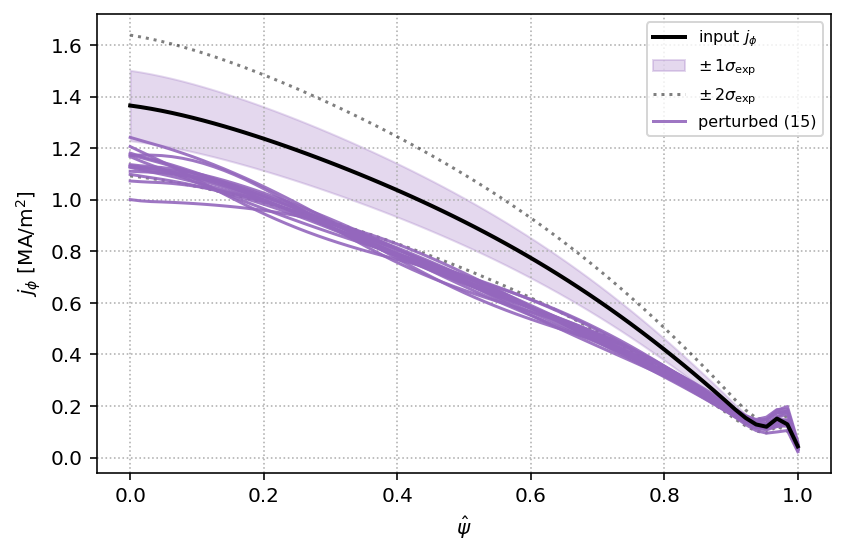

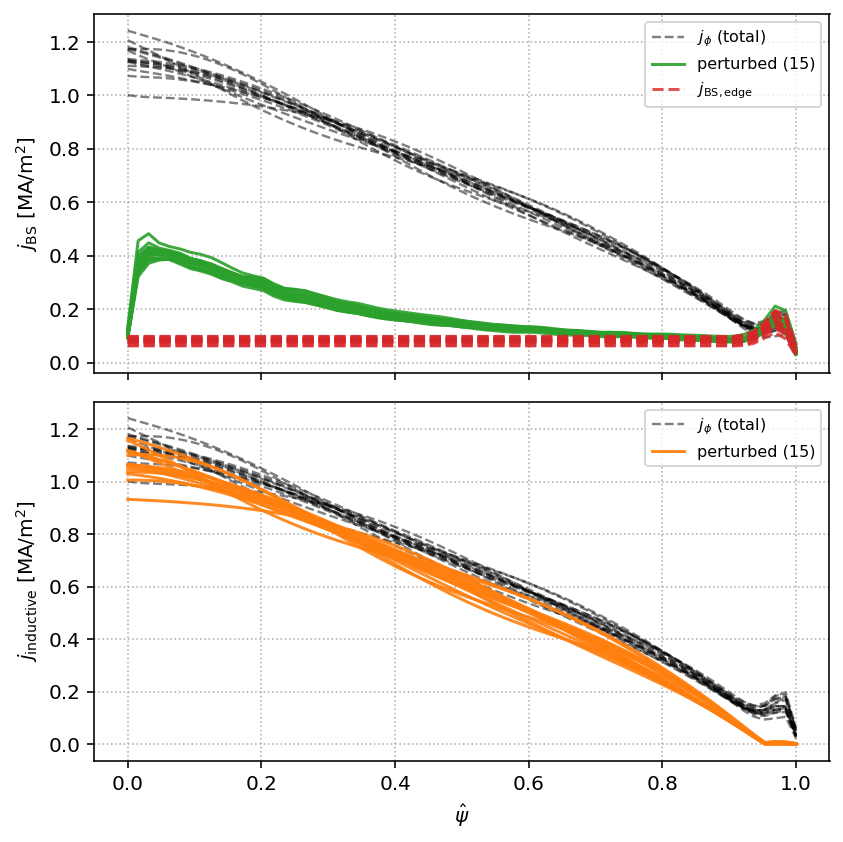

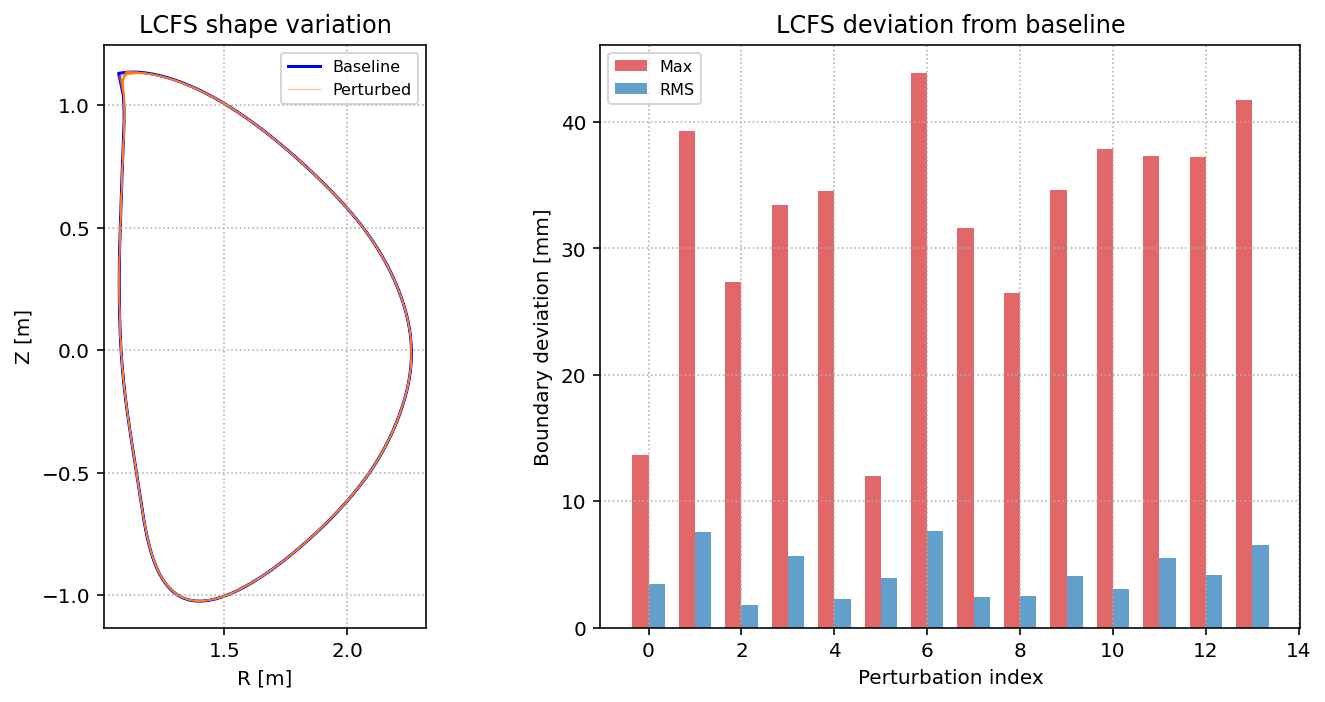

In [17]:
# Plot all bouquet panels
plot_bouquet(header, scan_value=0, mode='all')
plt.savefig(os.path.join(FIG_DIR, 'bouquet_all_profiles.png'), dpi=150, bbox_inches='tight')
print(f"Saved: {FIG_DIR}/bouquet_all_profiles.png")
plt.show()

Saved: figures/bouquet_kinetic.png


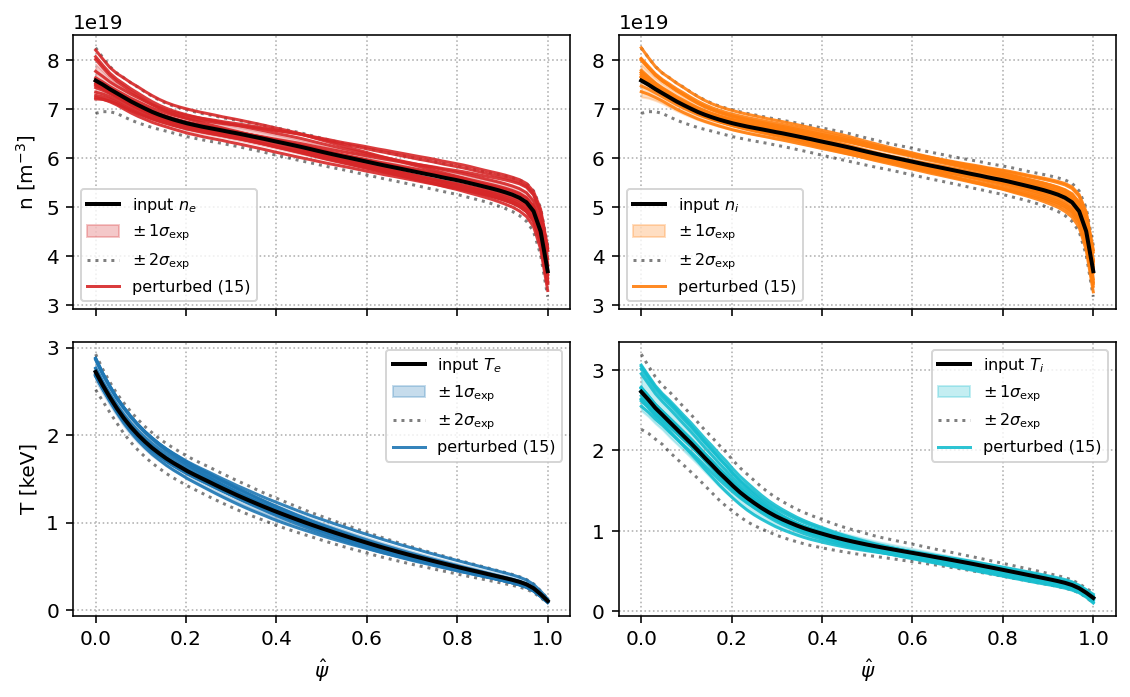

Saved: figures/bouquet_pressure.png


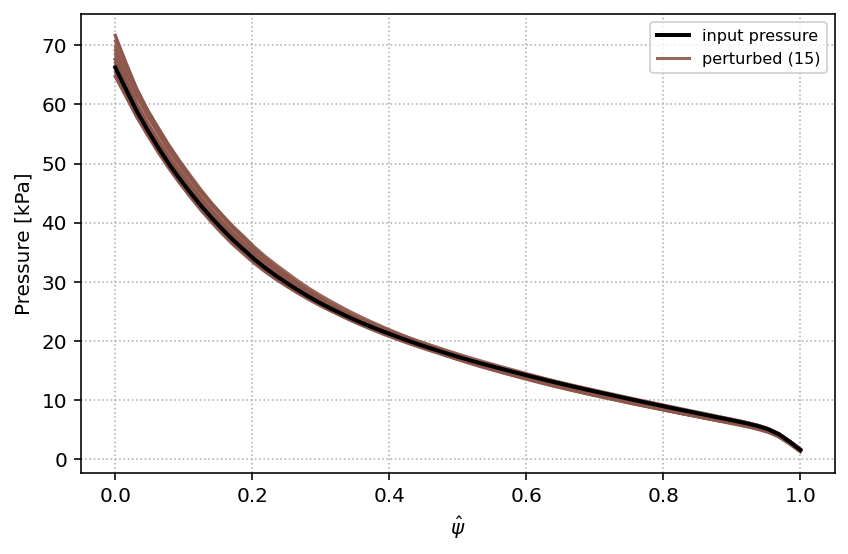

Saved: figures/bouquet_jphi.png


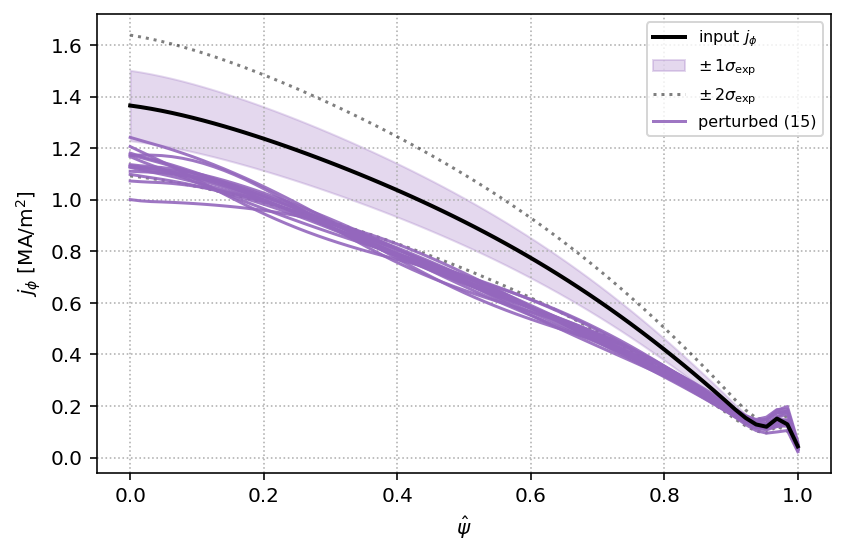

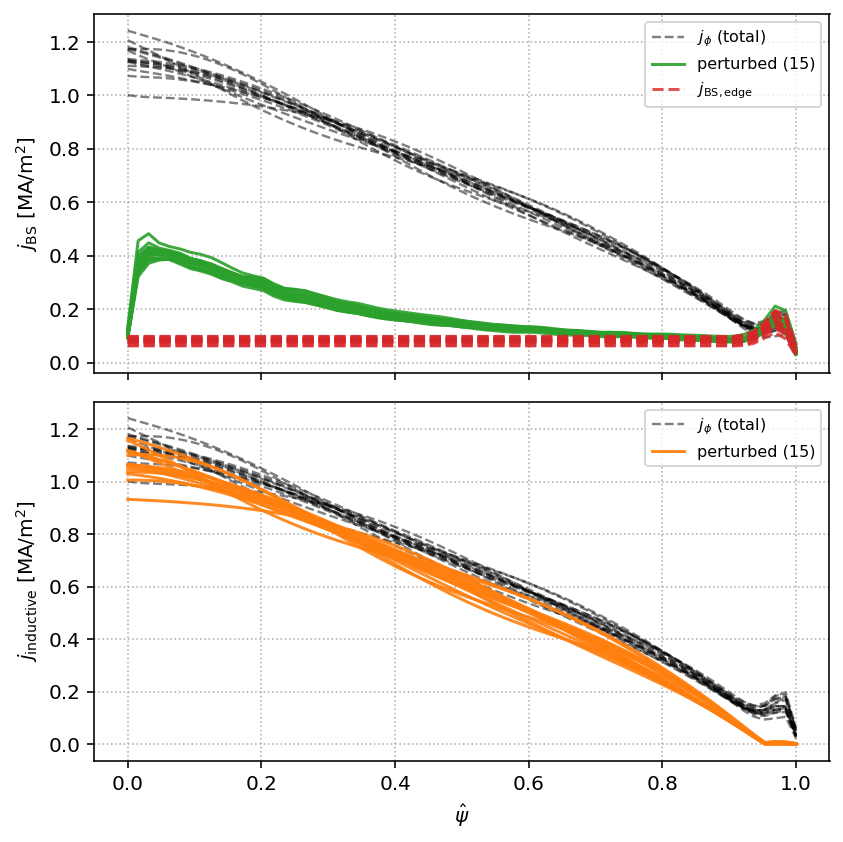

In [18]:
# Individual mode plots for clearer detail
for mode in ['kinetic', 'pressure', 'j-phi']:
    plot_bouquet(header, scan_value=0, mode=mode)
    fname = f'bouquet_{mode.replace("-", "")}.png'
    plt.savefig(os.path.join(FIG_DIR, fname), dpi=150, bbox_inches='tight')
    print(f"Saved: {FIG_DIR}/{fname}")
    plt.show()

## 9. Extract q-profiles and locate q = 4 surface

For each perturbed equilibrium stored in the HDF5 database, we:

1. Load the archived g-file bytes.
2. Read the q-profile from the geqdsk data.
3. Interpolate to find where q = 4 (if the surface exists within
   the plasma).

We also extract the baseline q-profile for comparison.


In [19]:
import h5py
from bouquet import read_eqdsk_from_bytes, load_equilibrium


def find_q_surface(psi_N_q, q_profile, q_target=4.0):
    """
    Find the psi_N location(s) where q = q_target.

    Uses linear interpolation between grid points where q crosses
    the target value.  Returns all crossings (there may be more
    than one if the q-profile is non-monotonic).

    Parameters
    ----------
    psi_N_q : ndarray
        Normalised flux grid for the q-profile.
    q_profile : ndarray
        Safety factor profile.
    q_target : float
        Target q value to locate.

    Returns
    -------
    list of float
        psi_N location(s) of the q = q_target surface.
        Empty list if the surface is not found.
    """
    crossings = []
    for i in range(len(q_profile) - 1):
        q0, q1 = q_profile[i], q_profile[i + 1]
        # Check if q_target is between q0 and q1
        if (q0 - q_target) * (q1 - q_target) <= 0 and q0 != q1:
            # Linear interpolation
            frac = (q_target - q0) / (q1 - q0)
            psi_crossing = psi_N_q[i] + frac * (psi_N_q[i + 1] - psi_N_q[i])
            crossings.append(psi_crossing)
    return crossings


print("q-surface finding function defined.")

q-surface finding function defined.


In [20]:
# ---- Extract baseline q-profile ----
# The baseline g-file q-profile
psi_N_baseline = eqdsk.psi_N
q_baseline = eqdsk.qpsi

q4_baseline = find_q_surface(psi_N_baseline, q_baseline, q_target=4.0)
print(f"Baseline q-profile: q(0) = {q_baseline[0]:.3f}, q(1) = {q_baseline[-1]:.3f}")
if q4_baseline:
    print(f"Baseline q=4 surface at psi_N = {q4_baseline[0]:.4f}")
else:
    print("WARNING: q=4 surface not found in baseline!")
    print(f"  q_max = {np.max(q_baseline):.3f} at psi_N = {psi_N_baseline[np.argmax(q_baseline)]:.4f}")

Baseline q-profile: q(0) = 1.818, q(1) = 20.425
Baseline q=4 surface at psi_N = 0.8068


In [21]:
# ---- Extract q-profiles from all perturbed equilibria ----
q4_locations = []       # psi_N of q=4 for each perturbed equilibrium
q_profiles_all = []     # all q-profiles for plotting
psiN_profiles_all = []  # corresponding psi_N grids

with h5py.File(f"{header}.h5", 'r') as hf:
    # Dynamically discover HDF5 layout
    # Layout is either: scan/{scan_val}/{count} or flat {count}
    if 'scan' in hf:
        scan_grp = hf['scan']
        scan_keys = list(scan_grp.keys())
        print(f"HDF5 layout: scan/ with keys {scan_keys}")
        equil_grp = scan_grp[scan_keys[0]]
    else:
        equil_grp = hf
        print("HDF5 layout: flat (no scan/ group)")

    eq_keys = sorted([k for k in equil_grp.keys() if k.isdigit()],
                     key=lambda k: int(k))

    print(f"Found {len(eq_keys)} equilibria in database (including baseline)")
    print()

    for eq_key in eq_keys:
        eq_grp = equil_grp[eq_key]
        eq_idx = int(eq_key)

        # Find eqdsk dataset by name ending in '.eqdsk'
        eqdsk_ds = [k for k in eq_grp.keys() if k.endswith('.eqdsk')]
        if eqdsk_ds:
            eqdsk_bytes = bytes(eq_grp[eqdsk_ds[0]][()])
            eq_data = read_eqdsk_from_bytes(eqdsk_bytes, read_geqdsk)

            psi_N_eq = eq_data.psi_N
            q_eq = eq_data.qpsi

            q_profiles_all.append(q_eq)
            psiN_profiles_all.append(psi_N_eq)

            # Find q=4
            q4_locs = find_q_surface(psi_N_eq, q_eq, q_target=4.0)

            label = 'baseline' if eq_idx == 0 else f'perturbed {eq_idx}'
            if q4_locs:
                # Take the outermost crossing (largest psi_N)
                q4_psiN = max(q4_locs)
                q4_locations.append(q4_psiN)
                print(f"  [{eq_key}] ({label}): q=4 at psi_N = {q4_psiN:.4f}")
            else:
                print(f"  [{eq_key}] ({label}): q=4 NOT FOUND (q_max = {np.max(q_eq):.3f})")
        else:
            print(f"  [{eq_key}]: no eqdsk dataset found")

q4_locations = np.array(q4_locations)
print(f"\nq=4 found in {len(q4_locations)} / {len(eq_keys)} equilibria")

HDF5 layout: scan/ with keys ['0']
Found 15 equilibria in database (including baseline)

  [0] (baseline): q=4 at psi_N = 0.7939
  [1] (perturbed 1): q=4 at psi_N = 0.8059
  [2] (perturbed 2): q=4 at psi_N = 0.8047
  [3] (perturbed 3): q=4 at psi_N = 0.7998
  [4] (perturbed 4): q=4 at psi_N = 0.7956
  [5] (perturbed 5): q=4 at psi_N = 0.7986
  [6] (perturbed 6): q=4 at psi_N = 0.8006
  [7] (perturbed 7): q=4 at psi_N = 0.8019
  [8] (perturbed 8): q=4 at psi_N = 0.8015
  [9] (perturbed 9): q=4 at psi_N = 0.8001
  [10] (perturbed 10): q=4 at psi_N = 0.7987
  [11] (perturbed 11): q=4 at psi_N = 0.8076
  [12] (perturbed 12): q=4 at psi_N = 0.8027
  [13] (perturbed 13): q=4 at psi_N = 0.7943
  [14] (perturbed 14): q=4 at psi_N = 0.7989

q=4 found in 15 / 15 equilibria


## 10. q-profile comparison

Overlay all perturbed q-profiles against the baseline, with a
horizontal line at q = 4 to show the spread in crossing locations.

Saved: figures/q_profiles_comparison.png


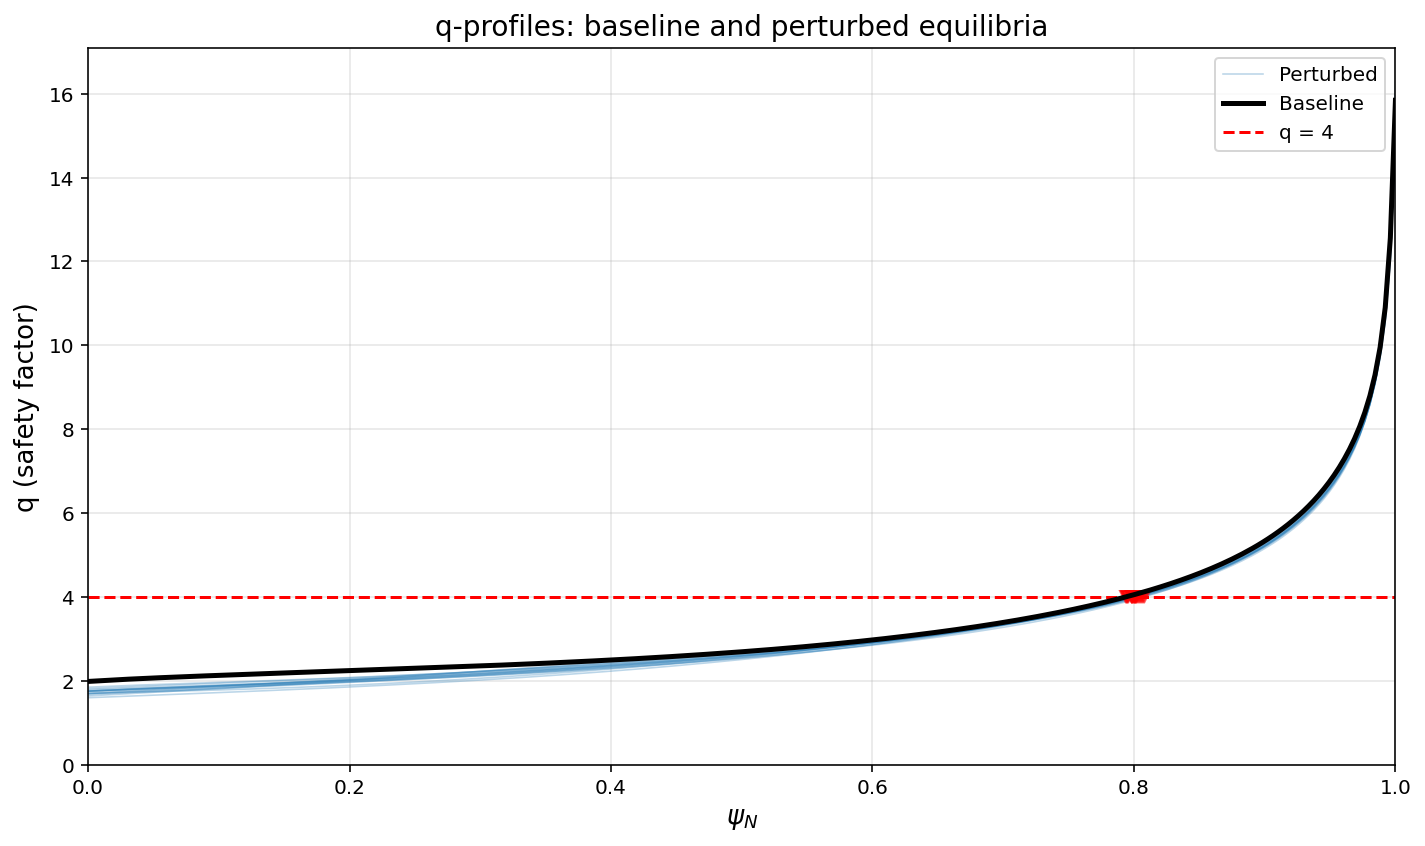

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Plot perturbed q-profiles (light blue spaghetti)
for i, (psiN_q, q_prof) in enumerate(zip(psiN_profiles_all, q_profiles_all)):
    if i == 0:
        continue  # skip baseline (plotted separately)
    ax.plot(psiN_q, q_prof, '-', color='tab:blue', alpha=0.3, lw=0.8,
            label='Perturbed' if i == 1 else None)

# Plot baseline q-profile (black, thick)
if len(psiN_profiles_all) > 0:
    ax.plot(psiN_profiles_all[0], q_profiles_all[0], 'k-', lw=2.5,
            label='Baseline', zorder=10)

# q=4 reference line
ax.axhline(y=4.0, color='red', ls='--', lw=1.5, label='q = 4')

# Mark q=4 crossings
for q4_psi in q4_locations:
    ax.plot(q4_psi, 4.0, 'rv', ms=6, alpha=0.6, zorder=5)

ax.set_xlabel(r'$\psi_N$', fontsize=13)
ax.set_ylabel('q (safety factor)', fontsize=13)
ax.set_title('q-profiles: baseline and perturbed equilibria', fontsize=14)
ax.set_xlim(0, 1.0)
ax.set_ylim(0, max(8, np.max([np.max(q) for q in q_profiles_all]) * 1.05))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'q_profiles_comparison.png'), dpi=150, bbox_inches='tight')
print(f"Saved: {FIG_DIR}/q_profiles_comparison.png")
plt.show()

## 11. Histogram of q = 4 surface location and 95% confidence interval

### Statistical approach

With 15 samples, we report:
- **Mean** and **standard deviation** of the q = 4 location.
- **95% confidence interval** computed as the 2.5th and 97.5th
  percentiles of the sample distribution.  For 15 samples this is
  equivalent to approximately the min and max of the sample.

q = 4 surface location statistics
  N samples:         15
  Mean:              psi_N = 0.8003
  Median:            psi_N = 0.8001
  Std deviation:     0.0040
  95% CI:            [0.7941, 0.8070]
  Range:             [0.7939, 0.8076]

Saved: figures/q4_histogram.png


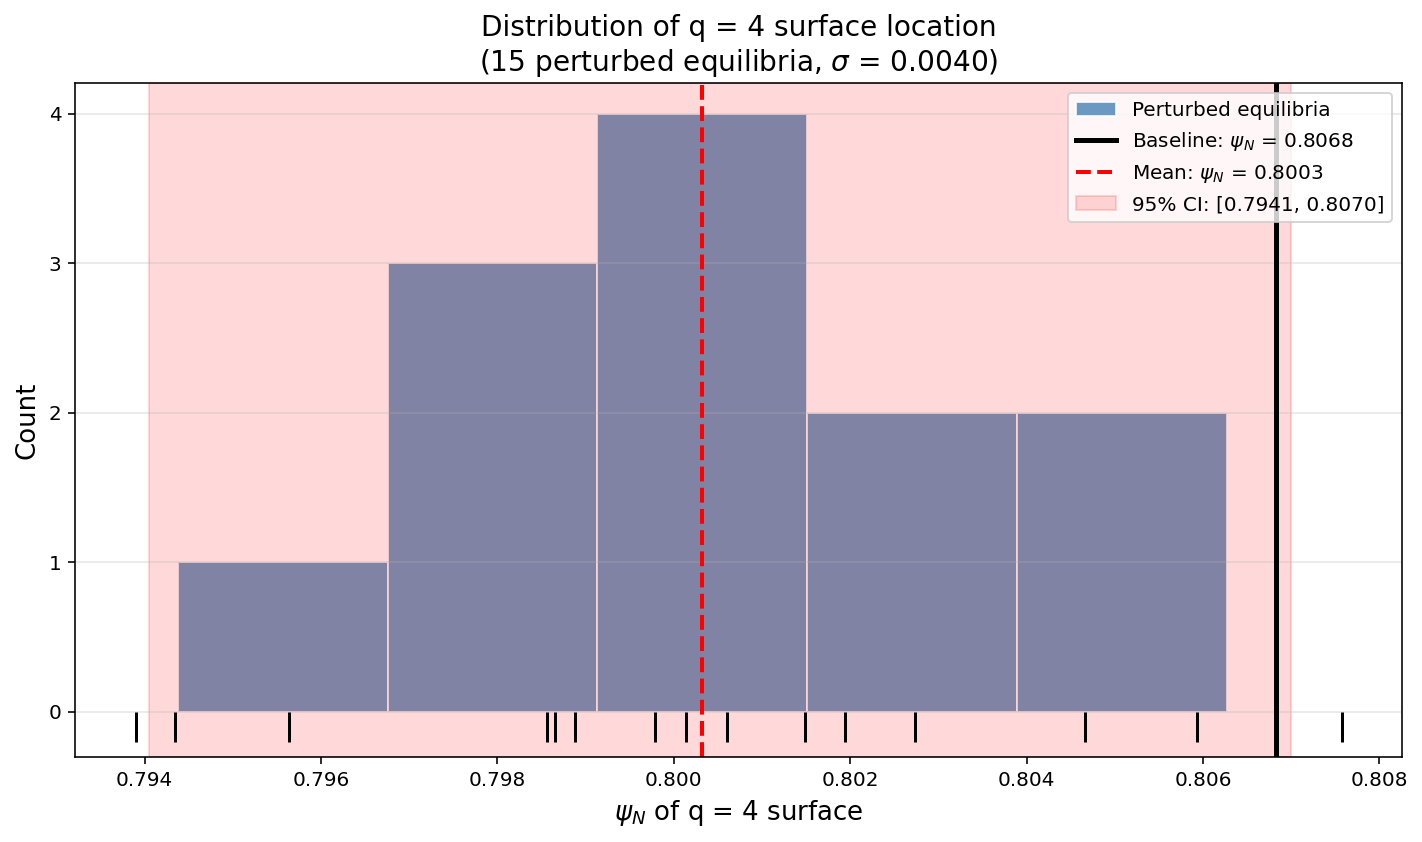

In [23]:
if len(q4_locations) >= 2:
    # ---- Statistics ----
    q4_mean = np.mean(q4_locations)
    q4_std  = np.std(q4_locations, ddof=1)  # sample std
    q4_lo   = np.percentile(q4_locations, 2.5)
    q4_hi   = np.percentile(q4_locations, 97.5)
    q4_median = np.median(q4_locations)

    print("="*60)
    print("q = 4 surface location statistics")
    print("="*60)
    print(f"  N samples:         {len(q4_locations)}")
    print(f"  Mean:              psi_N = {q4_mean:.4f}")
    print(f"  Median:            psi_N = {q4_median:.4f}")
    print(f"  Std deviation:     {q4_std:.4f}")
    print(f"  95% CI:            [{q4_lo:.4f}, {q4_hi:.4f}]")
    print(f"  Range:             [{np.min(q4_locations):.4f}, {np.max(q4_locations):.4f}]")
    print("="*60)

    # ---- Histogram ----
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    # Choose bins: use ~8-12 bins for 15 samples, or Freedman-Diaconis
    n_bins = min(12, max(5, int(np.sqrt(len(q4_locations)))))
    # Ensure bins span the full range with some padding
    bin_pad = 0.5 * q4_std if q4_std > 0 else 0.01
    bins = np.linspace(q4_mean - 3*bin_pad, q4_mean + 3*bin_pad, n_bins + 1)

    ax.hist(q4_locations, bins=bins, color='steelblue', edgecolor='white',
            alpha=0.8, label='Perturbed equilibria')

    # Mark baseline
    if q4_baseline:
        ax.axvline(q4_baseline[0], color='black', lw=2.5, ls='-',
                   label=f'Baseline: $\\psi_N$ = {q4_baseline[0]:.4f}')

    # Mark mean
    ax.axvline(q4_mean, color='red', lw=2, ls='--',
               label=f'Mean: $\\psi_N$ = {q4_mean:.4f}')

    # 95% CI shading
    ax.axvspan(q4_lo, q4_hi, alpha=0.15, color='red',
               label=f'95% CI: [{q4_lo:.4f}, {q4_hi:.4f}]')

    # Rug plot (individual observations)
    ax.plot(q4_locations, np.zeros_like(q4_locations) - 0.1,
            '|', color='k', ms=15, mew=1.5)

    ax.set_xlabel(r'$\psi_N$ of q = 4 surface', fontsize=13)
    ax.set_ylabel('Count', fontsize=13)
    ax.set_title(f'Distribution of q = 4 surface location\n'
                 f'({len(q4_locations)} perturbed equilibria, '
                 f'$\\sigma$ = {q4_std:.4f})', fontsize=14)
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(bottom=-0.3)

    plt.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, 'q4_histogram.png'), dpi=150, bbox_inches='tight')
    print(f"\nSaved: {FIG_DIR}/q4_histogram.png")
    plt.show()

else:
    print(f"WARNING: Only {len(q4_locations)} q=4 crossings found.")
    print("Cannot compute meaningful statistics. Check q-profiles above.")

## 12. Summary

Print the final results in a compact table for easy reference and
inclusion in reports.

In [24]:
print("\n" + "="*70)
print("  RESULTS: q = 4 Surface Location Uncertainty for Shot 199749")
print("="*70)
print(f"  Equilibrium:       g199749.03350  (DIII-D)")
print(f"  Bouquet size:      {n_equils} perturbed equilibria")
print(f"  Uncertainty basis: Data-driven (raw Thomson/CER scatter)")
print(f"  GPR length scales: n={n_ls}, T={t_ls}, j={j_ls}")
print(f"  j_BS scale range:  {jBS_scale_range}")
print()

if len(q4_locations) >= 2:
    print(f"  q=4 locations found: {len(q4_locations)} / {n_equils + 1} equilibria")
    print()
    if q4_baseline:
        print(f"  Baseline q=4:      psi_N = {q4_baseline[0]:.4f}")
    print(f"  Mean q=4:          psi_N = {q4_mean:.4f}")
    print(f"  Std deviation:     {q4_std:.4f}")
    print(f"  95% CI:            psi_N in [{q4_lo:.4f}, {q4_hi:.4f}]")
    print()
    print(f"  The q=4 surface is located at psi_N = {q4_mean:.4f} +/- {q4_std:.4f}")
    print(f"  95% CI width:      {q4_hi - q4_lo:.4f} in psi_N")
else:
    print(f"  Insufficient q=4 crossings ({len(q4_locations)}) for statistics.")

print("="*70)

# ---- List all saved figures ----
print(f"\nSaved figures in {FIG_DIR}/:\n")
for f in sorted(os.listdir(FIG_DIR)):
    if f.endswith('.png'):
        fpath = os.path.join(FIG_DIR, f)
        fsize = os.path.getsize(fpath) / 1024
        print(f"  {f:40s}  ({fsize:.0f} kB)")


  RESULTS: q = 4 Surface Location Uncertainty for Shot 199749
  Equilibrium:       g199749.03350  (DIII-D)
  Bouquet size:      15 perturbed equilibria
  Uncertainty basis: Data-driven (raw Thomson/CER scatter)
  GPR length scales: n=0.6, T=0.5, j=0.3
  j_BS scale range:  [0.8, 1.2]

  q=4 locations found: 15 / 16 equilibria

  Baseline q=4:      psi_N = 0.8068
  Mean q=4:          psi_N = 0.8003
  Std deviation:     0.0040
  95% CI:            psi_N in [0.7941, 0.8070]

  The q=4 surface is located at psi_N = 0.8003 +/- 0.0040
  95% CI width:      0.0129 in psi_N

Saved figures in figures/:

  bouquet_all_profiles.png                  (80 kB)
  bouquet_jphi.png                          (183 kB)
  bouquet_kinetic.png                       (184 kB)
  bouquet_pressure.png                      (56 kB)
  q4_histogram.png                          (50 kB)
  q_profiles_comparison.png                 (63 kB)
  reconstruction_comparison.png             (4 kB)
  uncertainty_estimation.png      

In [25]:
# ---- Detailed table of all q=4 locations ----
print("\nIndividual q=4 surface locations:")
print(f"{'Equilibrium':>15s}  {'psi_N of q=4':>14s}  {'Delta from mean':>16s}")
print("-" * 50)

with h5py.File(f"{header}.h5", 'r') as hf:
    # Dynamically discover HDF5 layout (same as §9)
    if 'scan' in hf:
        scan_grp = hf['scan']
        scan_keys = list(scan_grp.keys())
        equil_grp = scan_grp[scan_keys[0]]
    else:
        equil_grp = hf

    eq_keys = sorted([k for k in equil_grp.keys() if k.isdigit()],
                     key=lambda k: int(k))

    for eq_key in eq_keys:
        eq_grp = equil_grp[eq_key]
        eq_idx = int(eq_key)

        eqdsk_ds = [k for k in eq_grp.keys() if k.endswith('.eqdsk')]
        if eqdsk_ds:
            eqdsk_bytes = bytes(eq_grp[eqdsk_ds[0]][()])
            eq_data = read_eqdsk_from_bytes(eqdsk_bytes, read_geqdsk)
            q4_locs = find_q_surface(eq_data.psi_N, eq_data.qpsi, q_target=4.0)
            label = 'Baseline' if eq_idx == 0 else f'Perturbed {eq_idx}'
            if q4_locs:
                q4_val = max(q4_locs)
                delta = q4_val - q4_mean if len(q4_locations) >= 2 else 0.0
                print(f"{label:>15s}  {q4_val:14.4f}  {delta:+16.4f}")
            else:
                print(f"{label:>15s}  {'not found':>14s}  {'---':>16s}")

print("-" * 50)


Individual q=4 surface locations:
    Equilibrium    psi_N of q=4   Delta from mean
--------------------------------------------------
       Baseline          0.7939           -0.0064
    Perturbed 1          0.8059           +0.0056
    Perturbed 2          0.8047           +0.0043
    Perturbed 3          0.7998           -0.0005
    Perturbed 4          0.7956           -0.0047
    Perturbed 5          0.7986           -0.0018
    Perturbed 6          0.8006           +0.0003
    Perturbed 7          0.8019           +0.0016
    Perturbed 8          0.8015           +0.0012
    Perturbed 9          0.8001           -0.0002
   Perturbed 10          0.7987           -0.0017
   Perturbed 11          0.8076           +0.0073
   Perturbed 12          0.8027           +0.0024
   Perturbed 13          0.7943           -0.0060
   Perturbed 14          0.7989           -0.0014
--------------------------------------------------
